In [1]:
import numpy as np

import scanpy as sc
import matplotlib.pyplot as plt 


import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [3]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [4]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [5]:
S_mer = adata_mer.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
S_mer = get_hemi(S_mer, mesh_LC)    

adata_mer.obsm['spatial'] = S_mer

In [74]:
yourgenelist = ['Adcy2',
 'Aldoa',
 'Asah1',
 'Atp1a3',
 'Atp5a1',
 'Atp9a',
 'Cd63',
 'Chodl',
 'Cntn4',
 'Cntnap5b',
 'Col24a1',
 'Colq',
 'Cox6b1',
 'Ctsb',
 'Dab1',
 'Dgki',
 'Dnm3',
 'Dpp10',
 'Enpp2',
 'Erg',
 'Fxyd6',
 'Gaa',
 'Gal',
 'Il1rapl1',
 'Inpp4b',
 'Itm2c',
 'Lhfpl3',
 'Luzp2',
 'Mapk11',
 'Mbp',
 'Necab2',
 'Nnat',
 'Nrg4',
 'Opcml',
 'Parn',
 'Pcp4',
 'Plscr4',
 'Plxdc2',
 'Ptprd',
 'Ptprk',
 'Rgs11',
 'Sgcz',
 'Slc38a11',
 'Sncg',
 'Spint2',
 'Ssbp2',
 'Sult4a1',
 'Tpcn2',
 'Tspan13',
 'Tspan7']
yourgenelist = np.array(yourgenelist)[[m in adata_mer.var_names for m in yourgenelist]]

In [75]:
yourgenelist

array(['Chodl', 'Col24a1', 'Necab2'], dtype='<U8')

In [76]:
yourgenelist[np.where([m in adata_mer.var_names for m in yourgenelist])[0]]

array(['Chodl', 'Col24a1', 'Necab2'], dtype='<U8')

In [79]:
np.repeat(((2,1),(0,1)))

array([2, 2, 2, 1, 1, 1, 0, 0, 0, 1, 1, 1])

In [81]:
((2,1),(0,1))*3

((2, 1), (0, 1), (2, 1), (0, 1), (2, 1), (0, 1))

In [82]:
yourgenelist

array(['Chodl', 'Col24a1', 'Necab2'], dtype='<U8')

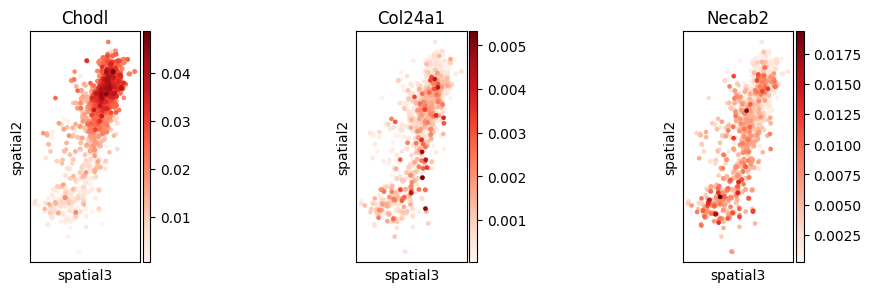

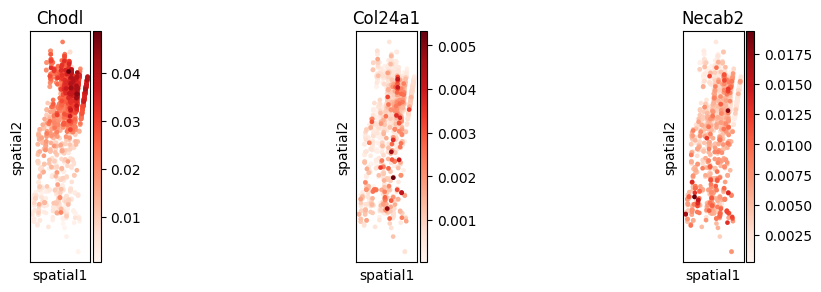

In [87]:
with plt.rc_context({"figure.figsize": (3,3)}):
    ax = sc.pl.embedding(adata_mer, basis = 'spatial', 
                     dimensions = (2,1),
                     cmap = 'Reds',
                     color = yourgenelist, 
                     show = False)
    for a in ax:
        a.set_aspect('equal')
        a.invert_yaxis()
    
with plt.rc_context({"figure.figsize": (3,3)}):
    ax = sc.pl.embedding(adata_mer, basis = 'spatial', 
                     dimensions = (0,1),
                     cmap = 'Reds',
                     color = yourgenelist, 
                     show = False)

    for a in ax:
        a.set_aspect('equal')
        a.invert_yaxis()    

NameError: name 'loadings_2_sorted' is not defined

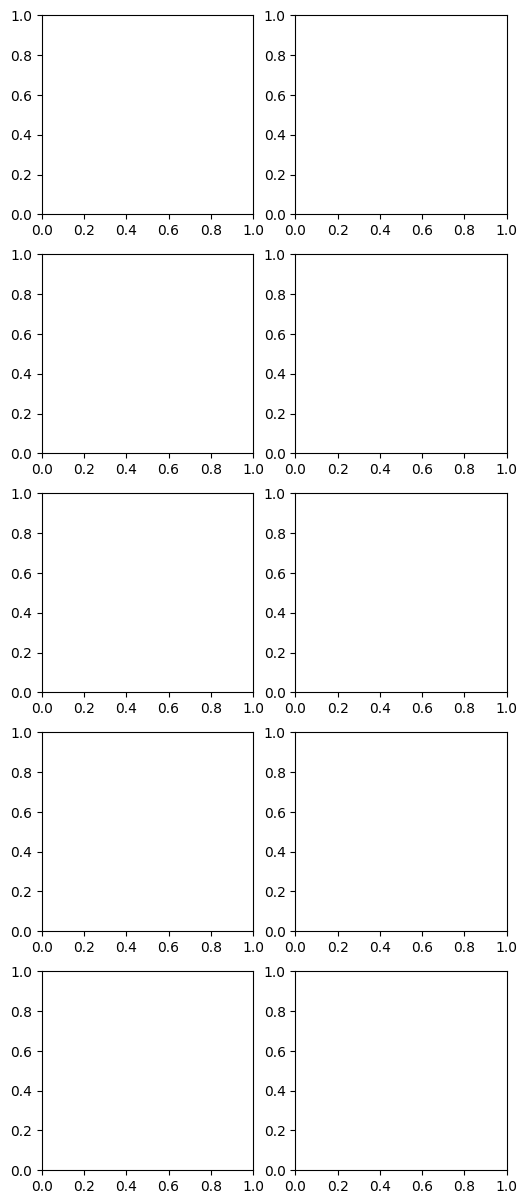

In [6]:
T = 5
fig, axes = plt.subplots(T,2,figsize=(6,3*T))

for i in range(T):
    top_gene = loadings_2_sorted.iloc[i]['gene']
    gene_index = list(adata_mer.var_names).index(top_gene)
    gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
    ordered = np.argsort(gene_expression)

    ax = axes[i,0]
    sc = ax.scatter(S_mer_scaled[ordered, 0], S_mer_scaled[ordered, 1], c=gene_expression[ordered], cmap='Blues',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_ylabel(top_gene)

    ax = axes[i,1]
    sc = ax.scatter(S_mer_scaled[ordered, 2], S_mer_scaled[ordered, 1], c=gene_expression[ordered], cmap='Blues',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()